## Cell 1 — Setup libraries


In [2]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from tensorflow.keras import layers, optimizers
import tensorflow.keras.backend as K

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    cohen_kappa_score, accuracy_score
)

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## Cell 2 — Load APTOS 2019 Dataset

Total images: 3662

Class distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Class distribution (%):
diagnosis
0    49.29
1    10.10
2    27.28
3     5.27
4     8.06
Name: proportion, dtype: float64


/tmp/ipykernel_58/3892897477.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=df, palette='viridis')


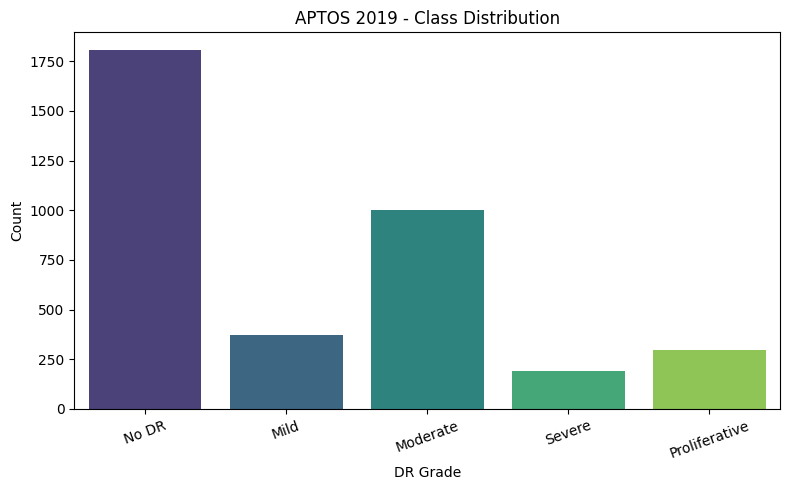

In [4]:
DATA_DIR = "/kaggle/input/competitions/aptos2019-blindness-detection/train_images/"
CSV_PATH = "/kaggle/input/competitions/aptos2019-blindness-detection/train.csv"

df = pd.read_csv(CSV_PATH)
df['id_code'] = df['id_code'] + '.png'
df['filepath'] = DATA_DIR + df['id_code']

print("Total images:", len(df))
print("\nClass distribution:")
print(df['diagnosis'].value_counts().sort_index())
print("\nClass distribution (%):")
print((df['diagnosis'].value_counts(normalize=True).sort_index() * 100).round(2))

# Class Names For Graph representation
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']

plt.figure(figsize=(8, 5))
sns.countplot(x='diagnosis', data=df, palette='viridis')
plt.title('APTOS 2019 - Class Distribution')
plt.xlabel('DR Grade')
plt.ylabel('Count')
plt.xticks(range(5), CLASS_NAMES, rotation=20)
plt.tight_layout()
plt.savefig('/kaggle/working/class_distribution.png', dpi=120)
plt.show()

## Cell 3 — Train / Validation / Test Split (Stratified)

In [5]:
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['diagnosis'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['diagnosis'], random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print("\nTrain distribution:\n", train_df['diagnosis'].value_counts().sort_index())
print("\nVal distribution:\n", val_df['diagnosis'].value_counts().sort_index())
print("\nTest distribution:\n", test_df['diagnosis'].value_counts().sort_index())


Train: 2563 | Val: 549 | Test: 550

Train distribution:
 diagnosis
0    1263
1     259
2     699
3     135
4     207
Name: count, dtype: int64

Val distribution:
 diagnosis
0    271
1     55
2    150
3     29
4     44
Name: count, dtype: int64

Test distribution:
 diagnosis
0    271
1     56
2    150
3     29
4     44
Name: count, dtype: int64


## Cell 4- Preprocessing — Green-Channel CLAHE

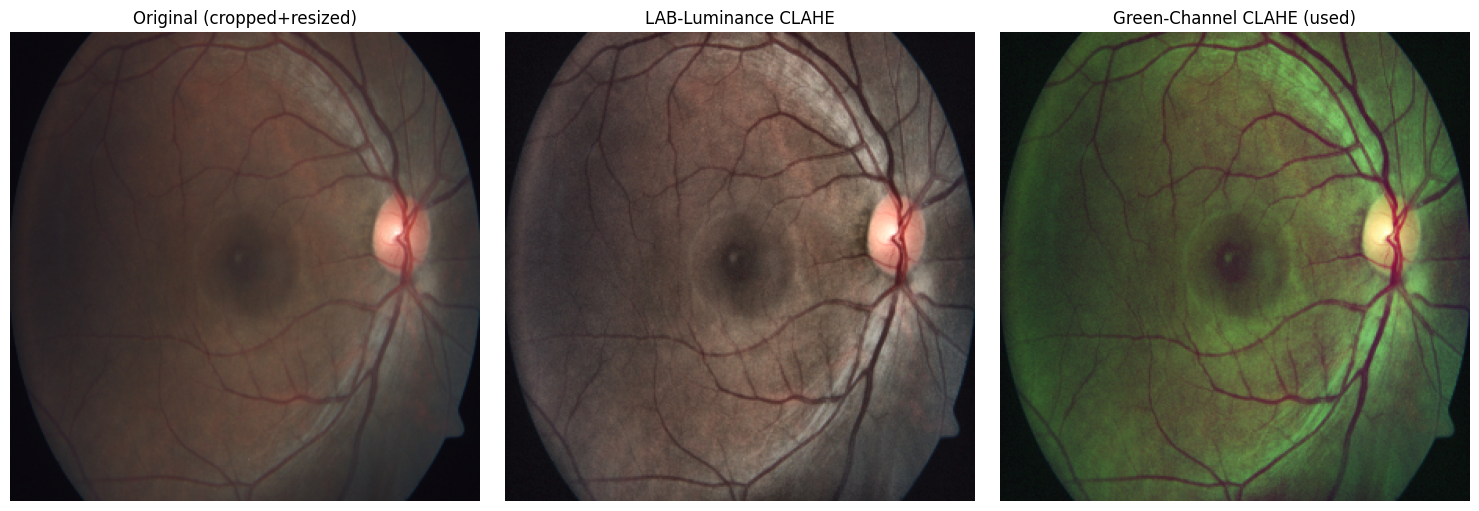

In [6]:
IMG_SIZE = 300
BATCH_SIZE = 16

def crop_image_from_gray(img, tol=7):
    """Remove black borders common in fundus images."""
    if img.ndim == 2:
        mask = img > tol
        return img[np.ix_(mask.any(1), mask.any(0))]
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    mask = gray_img > tol
    check_shape = img[np.ix_(mask.any(1), mask.any(0))].shape[0]
    if check_shape == 0:  # image is too dark, return original
        return img
    img1 = img[:, :, 0][np.ix_(mask.any(1), mask.any(0))]
    img2 = img[:, :, 1][np.ix_(mask.any(1), mask.any(0))]
    img3 = img[:, :, 2][np.ix_(mask.any(1), mask.any(0))]
    img = np.stack([img1, img2, img3], axis=-1)
    return img


def green_channel_clahe(img, clip_limit=3.0, tile_grid_size=(8, 8)):
    """
    Apply CLAHE to the green channel of an RGB fundus image and merge back.
    img: RGB uint8 numpy array
    """
    img = img.astype(np.uint8)
    r, g, b = cv2.split(img)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    g_enhanced = clahe.apply(g)

    enhanced = cv2.merge((r, g_enhanced, b))
    return enhanced


def preprocess_image(filepath):
    """Full preprocessing: read -> crop borders -> resize -> green-channel CLAHE."""
    img = cv2.imread(filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    img = green_channel_clahe(img, clip_limit=3.0, tile_grid_size=(8, 8))
    return img.astype(np.float32)

# Visual sanity check: raw vs green-channel-CLAHE vs LAB-CLAHE (for comparison)
def lab_clahe(img, clip_limit=2.0):
    img = img.astype(np.uint8)
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit)
    l = clahe.apply(l)
    lab = cv2.merge((l, a, b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

sample_path = train_df['filepath'].iloc[0]
raw = cv2.cvtColor(cv2.imread(sample_path), cv2.COLOR_BGR2RGB)
raw_resized = cv2.resize(crop_image_from_gray(raw), (IMG_SIZE, IMG_SIZE))
green_clahe_img = green_channel_clahe(raw_resized)
lab_clahe_img   = lab_clahe(raw_resized)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(raw_resized); axes[0].set_title('Original (cropped+resized)')
axes[1].imshow(lab_clahe_img); axes[1].set_title('LAB-Luminance CLAHE')
axes[2].imshow(green_clahe_img.astype(np.uint8)); axes[2].set_title('Green-Channel CLAHE (used)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.savefig('/kaggle/working/preprocessing_comparison.png', dpi=120)
plt.show()

## Cell 5- TF.data Pipeline with Augmentation

In [7]:
def tf_preprocess(filepath, label):
    def _process(fp):
        fp = fp.numpy().decode('utf-8')
        img = preprocess_image(fp)
        return img

    img = tf.py_function(func=_process, inp=[filepath], Tout=tf.float32)
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    # EfficientNet expects [0, 255] range scaled internally by preprocess_input
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label


def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    # small random rotation via rot90 (cheap, avoids interpolation artifacts)
    k = tf.random.uniform([], 0, 4, dtype=tf.int32)
    img = tf.image.rot90(img, k=k)
    return img, label


def make_dataset(dframe, training=False, batch_size=BATCH_SIZE):
    filepaths = dframe['filepath'].values
    labels = dframe['diagnosis'].values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    ds = ds.map(tf_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if training:
        ds = ds.shuffle(buffer_size=1024, seed=SEED)
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds


train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

print("Datasets ready.")


I0000 00:00:1781711116.155017      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781711116.160999      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets ready.


## Cell 6- Class Weights (for class-imbalance handling)

In [8]:
auto_class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['diagnosis']),
    y=train_df['diagnosis']
)
print("Auto (balanced) class weights:")
print(dict(enumerate(auto_class_weights)))

# Moderated weights — full 'balanced' weights tend to over-correct and hurt
# majority-class (No DR) precision, which drags down overall accuracy/QWK.
# We compress the range while still uplifting minority grades (1, 3, 4).
class_weights = {
    0: 0.6,
    1: 1.8,
    2: 1.0,
    3: 2.5,
    4: 2.2
}
print("\nFinal class weights used:")
print(class_weights)


Auto (balanced) class weights:
{0: np.float64(0.4058590657165479), 1: np.float64(1.9791505791505792), 2: np.float64(0.7333333333333333), 3: np.float64(3.797037037037037), 4: np.float64(2.476328502415459)}

Final class weights used:
{0: 0.6, 1: 1.8, 2: 1.0, 3: 2.5, 4: 2.2}


## Cell 7- CBAM (Convolutional Block Attention Module)

In [10]:
@tf.keras.utils.register_keras_serializable(package="MyModels")
class ReduceMean(layers.Layer):
    def call(self, x):
        return tf.reduce_mean(x, axis=-1, keepdims=True)
    def get_config(self):
        return super().get_config()

@tf.keras.utils.register_keras_serializable(package="MyModels")
class ReduceMax(layers.Layer):
    def call(self, x):
        return tf.reduce_max(x, axis=-1, keepdims=True)
    def get_config(self):
        return super().get_config()

def channel_attention(x, ratio=8):
    """Channel attention: squeeze-and-excitation style over channel axis."""
    C = x.shape[-1]

    shared_dense1 = layers.Dense(C // ratio, activation='relu', use_bias=False)
    shared_dense2 = layers.Dense(C, use_bias=False)

    avg = layers.GlobalAveragePooling2D()(x)
    avg = shared_dense1(avg)
    avg = shared_dense2(avg)

    mx = layers.GlobalMaxPooling2D()(x)
    mx = shared_dense1(mx)
    mx = shared_dense2(mx)

    combined = layers.Add()([avg, mx])
    scale = layers.Activation('sigmoid')(combined)
    scale = layers.Reshape((1, 1, C))(scale)
    return layers.Multiply()([x, scale])


def spatial_attention(x, kernel_size=7):
    """Spatial attention: highlights WHERE to focus using channel pooling."""
    avg_pool = ReduceMean()(x)
    max_pool = ReduceMax()(x)
    concat = layers.Concatenate()([avg_pool, max_pool])

    scale = layers.Conv2D(
        filters=1, kernel_size=kernel_size, padding='same',
        activation='sigmoid', use_bias=False
    )(concat)
    return layers.Multiply()([x, scale])


def cbam_block(x, ratio=8, kernel_size=7):
    x = channel_attention(x, ratio=ratio)
    x = spatial_attention(x, kernel_size=kernel_size)
    return x


## Cell 8- Ordinal-Aware Loss

In [11]:

# DR grading is **ordinal** (0 < 1 < 2 < 3 < 4) — misclassifying grade 4 as 0
# is far worse than misclassifying it as 3. Standard categorical/focal loss
# treats all misclassifications equally, which hurts QWK (which itself
# penalizes large rank errors more heavily).

# We combine:
# 1. **Categorical Focal Loss** — handles class imbalance, focuses on hard examples
# 2. **Ordinal Regression Loss (MSE on expected class)** — penalizes predictions
#    that are numerically far from the true grade

# Final loss = focal_loss + lambda * ordinal_mse

def categorical_focal_loss(gamma=2.0, alpha=0.25, num_classes=5):
    def loss(y_true, y_pred):
        y_true_oh = tf.one_hot(tf.cast(y_true, tf.int32), depth=num_classes)
        y_true_oh = tf.cast(y_true_oh, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        cross_entropy = -y_true_oh * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        fl = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(fl, axis=-1))
    return loss


def ordinal_mse_loss(num_classes=5):
    """Penalizes the squared distance between expected predicted grade and true grade."""
    class_values = tf.constant(np.arange(num_classes), dtype=tf.float32)

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(y_pred, tf.float32)
        expected_grade = tf.reduce_sum(y_pred * class_values, axis=-1)
        return tf.reduce_mean(tf.square(expected_grade - y_true))
    return loss


def combined_ordinal_focal_loss(gamma=2.0, alpha=0.25, lam=0.5, num_classes=5):
    focal = categorical_focal_loss(gamma=gamma, alpha=alpha, num_classes=num_classes)
    ordinal = ordinal_mse_loss(num_classes=num_classes)

    def loss(y_true, y_pred):
        return focal(y_true, y_pred) + lam * ordinal(y_true, y_pred)
    return loss


## Cell 9 — Quadratic Weighted Kappa (QWK) — Metric & Callback

In [12]:
def quadratic_weighted_kappa(y_true, y_pred):
    return cohen_kappa_score(y_true, y_pred, weights='quadratic')


class QWKEvalCallback(tf.keras.callbacks.Callback):
    """Computes QWK on the validation set after every epoch."""
    def __init__(self, val_dataset, val_labels):
        super().__init__()
        self.val_dataset = val_dataset
        self.val_labels = val_labels
        self.best_qwk = -1.0

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.val_dataset, verbose=0)
        y_pred = np.argmax(preds, axis=1)
        qwk = quadratic_weighted_kappa(self.val_labels, y_pred)
        logs = logs or {}
        logs['val_qwk'] = qwk
        if qwk > self.best_qwk:
            self.best_qwk = qwk
        print(f"  -- val_QWK: {qwk:.4f} (best: {self.best_qwk:.4f})")


val_labels_arr = val_df['diagnosis'].values

## Cell 10- Model — CBAM-Enhanced EfficientNet-B3 

In [13]:
from tensorflow.keras.applications import EfficientNetB3

base = EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base(inputs, training=False)

# CBAM attention block
x = cbam_block(x, ratio=8, kernel_size=7)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(5, activation='softmax', dtype='float32', name='predictions')(x)

model = tf.keras.Model(inputs, outputs, name='CBAM_EfficientNetB3_DR')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss=combined_ordinal_focal_loss(gamma=2.0, alpha=0.25, lam=0.5),
    metrics=['accuracy']
)

model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CBAM_EfficientNetB3_DR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb3      │ (None, 10, 10,    │ 10,783,535 │ input_layer_1[0]… │
│ (Functional)        │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 1536)      │          0 │ efficientnetb3[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 192)       │    294,912 │ global_average_p… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1536)      │    294,912 │ dense[0][0],      │
│                     │                   │            │ dense[1][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1536)      │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_1[1][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1536)      │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1,      │          0 │ activation[0][0]  │
│                     │ 1536)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 10, 10,    │          0 │ efficientnetb3[0… │
│                     │ 1536)             │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reduce_mean         │ (None, 10, 10, 1) │          0 │ multiply[0][0]    │
│ (ReduceMean)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reduce_max          │ (None, 10, 10, 1) │          0 │ multiply[0][0]    │
│ (ReduceMax)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 10, 10, 2) │          0 │ reduce_mean[0][0… │
│ (Concatenate)       │                   │            │ reduce_max[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 10, 10, 1) │         98 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_1          │ (None, 10, 10,    │          0 │ multiply[0][0],   │
│ (Multiply)          │ 1536)             │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1536)      │          0 │ multiply_1[0][0]  │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1536)      │      6,144 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 12,301,206 (46.93 MB)

 Trainable params: 1,513,575 (5.77 MB)

 Non-trainable params: 10,787,631 (41.15 MB)

## Cell 11- Phase 1 — Warm-up Training (Frozen Backbone)

In [14]:
phase1_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/kaggle/working/phase1_best.keras', save_best_only=True, monitor='val_loss'
    ),
    QWKEvalCallback(val_ds, val_labels_arr),
]

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=phase1_callbacks,
    class_weight=class_weights
)


Epoch 1/10


I0000 00:00:1781711422.436031     146 service.cc:152] XLA service 0x7c942c004100 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781711422.436079     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781711422.436085     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781711430.788300     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1781711483.429164     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5821 - loss: 0.7800  -- val_QWK: 0.7486 (best: 0.7486)
161/161 ━━━━━━━━━━━━━━━━━━━━ 645s 3s/step - accuracy: 0.6286 - loss: 0.6693 - val_accuracy: 0.7250 - val_loss: 0.6277 - val_qwk: 0.7486
Epoch 2/10
159/161 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6928 - loss: 0.4797  -- val_QWK: 0.1637 (best: 0.7486)
161/161 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.7043 - loss: 0.4771 - val_accuracy: 0.3570 - val_loss: 0.9209 - val_qwk: 0.1637
Epoch 3/10
159/161 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.7045 - loss: 0.4203  -- val_QWK: 0.7614 (best: 0.7614)
161/161 ━━━━━━━━━━━━━━━━━━━━ 395s 2s/step - accuracy: 0.7124 - loss: 0.4198 - val_accuracy: 0.7304 - val_loss: 0.3601 - val_qwk: 0.7614
Epoch 4/10
160/161 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.7258 - loss: 0.3670  -- val_QWK: 0.7313 (best: 0.7614)
161/161 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.7144 - loss: 0.4033 - val_accuracy: 0.6539 - val_loss: 0.4304 - val

## Cell 12- Phase 2 — Fine-Tuning (Unfreeze Top Layers + Cosine LR Decay)

In [15]:
# %%
# Unfreeze the top ~120 layers of EfficientNetB3 for fine-tuning
for layer in base.layers[-120:]:
    layer.trainable = True

steps_per_epoch = len(train_df) // BATCH_SIZE
total_fine_tune_epochs = 40
total_steps = total_fine_tune_epochs * steps_per_epoch

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=5e-5,
    decay_steps=total_steps,
    alpha=1e-6
)

model.compile(
    optimizer=optimizers.Adam(learning_rate=lr_schedule),
    loss=combined_ordinal_focal_loss(gamma=2.0, alpha=0.25, lam=0.5),
    metrics=['accuracy']
)

phase2_callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=8, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        '/kaggle/working/dr_model.keras', save_best_only=True, monitor='val_loss'
    ),
    QWKEvalCallback(val_ds, val_labels_arr),
]

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_fine_tune_epochs,
    callbacks=phase2_callbacks,
    class_weight=class_weights
)

Epoch 1/40


2026-06-17 17:13:51.364252: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 17:13:51.520197: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 17:13:51.717804: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 17:13:51.896968: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


159/161 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.6529 - loss: 0.6129

2026-06-17 17:18:09.898671: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 17:18:10.059151: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 17:18:10.251241: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 17:18:10.428713: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6532 - loss: 0.6116  -- val_QWK: 0.8528 (best: 0.8528)
161/161 ━━━━━━━━━━━━━━━━━━━━ 710s 3s/step - accuracy: 0.6758 - loss: 0.5072 - val_accuracy: 0.7723 - val_loss: 0.3150 - val_qwk: 0.8528
Epoch 2/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7402 - loss: 0.3462  -- val_QWK: 0.8467 (best: 0.8528)
161/161 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.7448 - loss: 0.3270 - val_accuracy: 0.7832 - val_loss: 0.2662 - val_qwk: 0.8467
Epoch 3/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7593 - loss: 0.3517  -- val_QWK: 0.8469 (best: 0.8528)
161/161 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.7632 - loss: 0.3099 - val_accuracy: 0.7887 - val_loss: 0.2633 - val_qwk: 0.8469
Epoch 4/40
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7919 - loss: 0.2837  -- val_QWK: 0.8359 (best: 0.8528)
161/161 ━━━━━━━━━━━━━━━━━━━━ 404s 2s/step - accuracy: 0.7737 - loss: 0.2869 - val_accuracy: 0.7796 - val_loss: 0.2758 - val

## Cell -13 Training Curves

Phase 1 - Final Train Accuracy: 76.20%
Phase 1 - Final Val Accuracy  : 77.60%

Phase 2 - Final Train Accuracy: 86.38%
Phase 2 - Final Val Accuracy  : 81.42%

Overall Final Train Accuracy  : 86.38%
Overall Final Val Accuracy    : 81.42%
Best Val Accuracy (any epoch) : 82.33% (epoch 31)




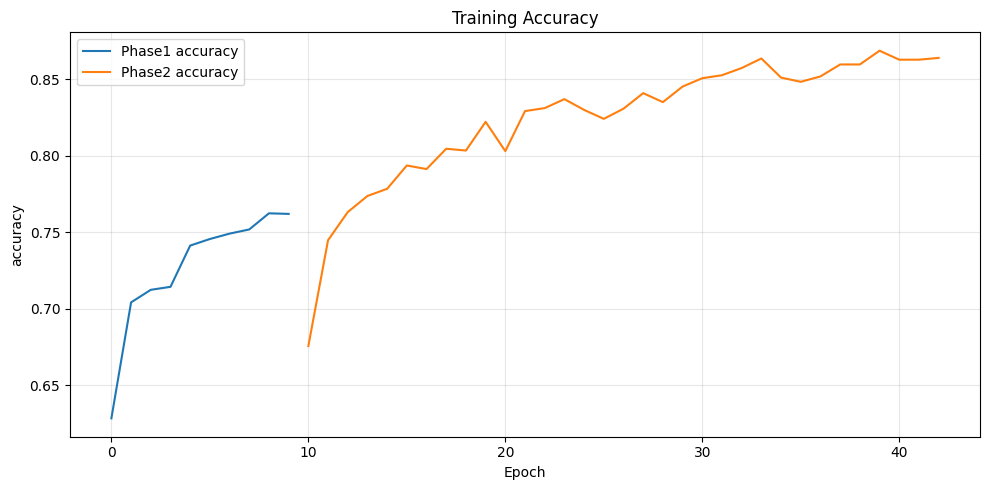

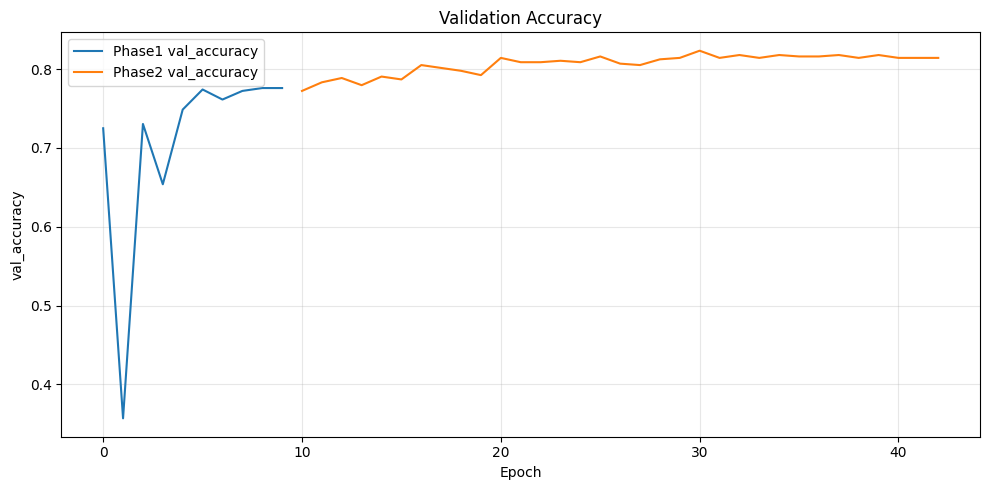

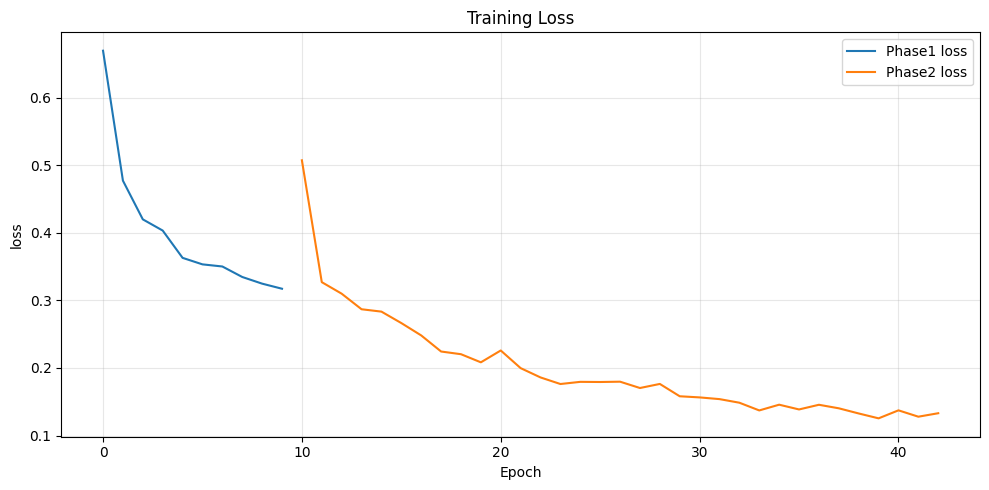

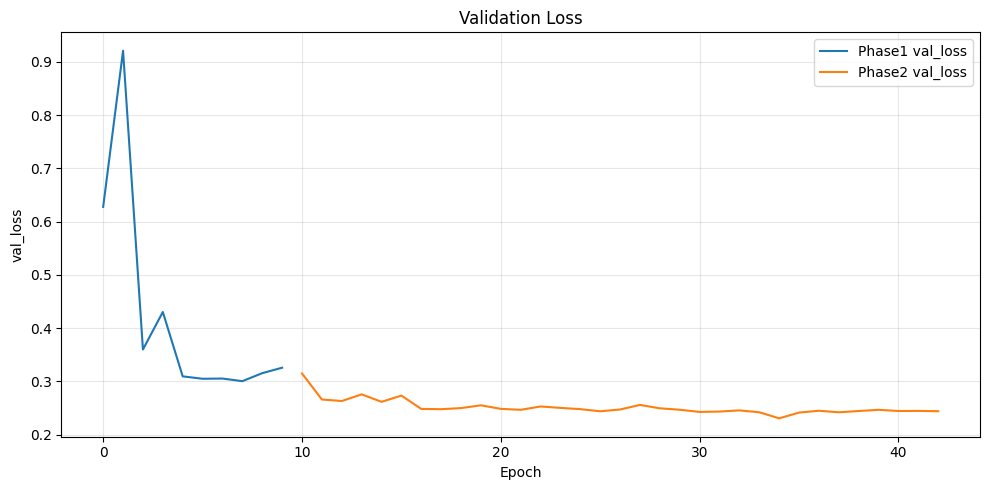

In [16]:
## 13. Training Curves

# %%
# Phase 1 final values
p1_train_acc = history1.history['accuracy'][-1]
p1_val_acc   = history1.history['val_accuracy'][-1]

# Phase 2 final values
p2_train_acc = history2.history['accuracy'][-1]
p2_val_acc   = history2.history['val_accuracy'][-1]

# Best validation accuracy across both phases
all_val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
best_val_acc = max(all_val_acc)
best_epoch = all_val_acc.index(best_val_acc) + 1

print("Phase 1 - Final Train Accuracy: {:.2f}%".format(p1_train_acc * 100))
print("Phase 1 - Final Val Accuracy  : {:.2f}%".format(p1_val_acc * 100))
print()
print("Phase 2 - Final Train Accuracy: {:.2f}%".format(p2_train_acc * 100))
print("Phase 2 - Final Val Accuracy  : {:.2f}%".format(p2_val_acc * 100))
print()
print("Overall Final Train Accuracy  : {:.2f}%".format(p2_train_acc * 100))
print("Overall Final Val Accuracy    : {:.2f}%".format(p2_val_acc * 100))
print("Best Val Accuracy (any epoch) : {:.2f}% (epoch {})".format(best_val_acc * 100, best_epoch))

print ("\n")

def plot_history(h1, h2, metric, title):
    plt.figure(figsize=(10, 5))
    vals1 = h1.history.get(metric, [])
    vals2 = h2.history.get(metric, [])
    plt.plot(range(len(vals1)), vals1, label=f'Phase1 {metric}')
    plt.plot(range(len(vals1), len(vals1) + len(vals2)), vals2, label=f'Phase2 {metric}')
    plt.title(title)
    plt.xlabel('Epoch')
    plt.ylabel(metric)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/{metric}_curve.png', dpi=120)
    plt.show()

plot_history(history1, history2, 'accuracy', 'Training Accuracy')
plot_history(history1, history2, 'val_accuracy', 'Validation Accuracy')
plot_history(history1, history2, 'loss', 'Training Loss')
plot_history(history1, history2, 'val_loss', 'Validation Loss')


## Cell 14- Final Evaluation On Test set

In [17]:
 

# %%  Final Evaluation on Test Set
model = tf.keras.models.load_model(
    '/kaggle/working/dr_model.keras',
    custom_objects={
        'loss': combined_ordinal_focal_loss(gamma=2.0, alpha=0.25, lam=0.5),
        'ReduceMean': ReduceMean,
        'ReduceMax': ReduceMax
    }
)

y_true, y_pred, y_probs = [], [], []
for x_batch, y_batch in test_ds:
    preds = model.predict(x_batch, verbose=0)
    y_true.extend(y_batch.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
    y_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

test_accuracy = accuracy_score(y_true, y_pred)
test_qwk = cohen_kappa_score(y_true, y_pred, weights='quadratic')

print(f"\n{'='*50}")
print(f"TEST ACCURACY : {test_accuracy*100:.2f}%")
print(f"TEST QWK      : {test_qwk:.4f}")
print(f"{'='*50}\n")

print("Classification Report (Per-Grade):")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))



TEST ACCURACY : 82.55%
TEST QWK      : 0.9035

Classification Report (Per-Grade):
               precision    recall  f1-score   support

        No DR     0.9779    0.9815    0.9797       271
         Mild     0.6087    0.5000    0.5490        56
     Moderate     0.7356    0.8533    0.7901       150
       Severe     0.4762    0.3448    0.4000        29
Proliferative     0.5946    0.5000    0.5432        44

     accuracy                         0.8255       550
    macro avg     0.6786    0.6359    0.6524       550
 weighted avg     0.8171    0.8255    0.8187       550



## Cell 15- Confusion Matrix

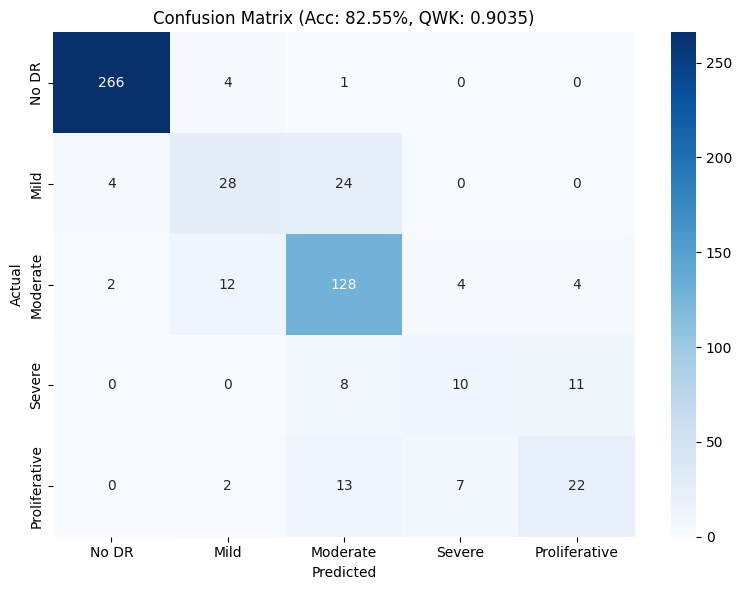

In [18]:
#  Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix (Acc: {test_accuracy*100:.2f}%, QWK: {test_qwk:.4f})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=120)
plt.show()



## Cell 16- Save The Matrix Summary

In [21]:

# Save metrics summary to a file for the report/submission

with open('/kaggle/working/final_metrics.txt', 'w') as f:
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test QWK: {test_qwk*100:.2f}%\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))
print("Saved final_metrics.txt")

# Save weights (FIXED NAME)
model.save_weights('/kaggle/working/dr_model.weights.h5')
print('dr_model.weights.h5 saved!')

Saved final_metrics.txt
dr_model.weights.h5 saved!


## Cell 17- Grad-CAM Explainabilty

In [23]:
# Grad-CAM utility — two separate fresh models (backbone + head), weights loaded

from tensorflow.keras.applications import EfficientNetB3

# ---- Backbone model: image -> feature map ----
gc_base = EfficientNetB3(
    include_top=False,
    weights=None,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
backbone_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
backbone_feat = gc_base(backbone_inputs, training=False)
backbone_model = tf.keras.Model(backbone_inputs, backbone_feat, name="gradcam_backbone")

# ---- Head model: feature map -> predictions (CBAM + classification head) ----
feat_shape = backbone_feat.shape[1:]  # (10, 10, 1536)
head_inputs = tf.keras.Input(shape=feat_shape)
hx = cbam_block(head_inputs, ratio=8, kernel_size=7)

hx = layers.GlobalAveragePooling2D()(hx)
hx = layers.BatchNormalization()(hx)
hx = layers.Dropout(0.4)(hx)

hx = layers.Dense(512, activation='relu')(hx)
hx = layers.BatchNormalization()(hx)
hx = layers.Dropout(0.3)(hx)

hx = layers.Dense(256, activation='relu')(hx)
hx = layers.Dropout(0.2)(hx)

head_outputs = layers.Dense(5, activation='softmax', dtype='float32', name='predictions')(hx)
head_model = tf.keras.Model(head_inputs, head_outputs, name="gradcam_head")

# ---- Build a full model with the SAME architecture, load trained weights ----
gc_inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
gc_feat = gc_base(gc_inputs, training=False)
gc_x = cbam_block(gc_feat, ratio=8, kernel_size=7)
gc_x = layers.GlobalAveragePooling2D()(gc_x)
gc_x = layers.BatchNormalization()(gc_x)
gc_x = layers.Dropout(0.4)(gc_x)
gc_x = layers.Dense(512, activation='relu')(gc_x)
gc_x = layers.BatchNormalization()(gc_x)
gc_x = layers.Dropout(0.3)(gc_x)
gc_x = layers.Dense(256, activation='relu')(gc_x)
gc_x = layers.Dropout(0.2)(gc_x)
gc_outputs = layers.Dense(5, activation='softmax', dtype='float32', name='predictions')(gc_x)
gc_model = tf.keras.Model(gc_inputs, gc_outputs, name='CBAM_EfficientNetB3_DR_GradCAM')

gc_model.load_weights('/kaggle/working/dr_model.keras')
print("Full model weights loaded.")

# ---- Copy weights from gc_model into head_model (positional matching) ----
# Both gc_model (after the backbone) and head_model (after its Input) were
# built by calling the exact same sequence of layer constructors
# (cbam_block + classification head), so their layers align positionally.

gc_backbone_idx = None
for i, l in enumerate(gc_model.layers):
    if l is gc_base:
        gc_backbone_idx = i
        break
assert gc_backbone_idx is not None, "Could not locate gc_base inside gc_model.layers"

gc_post_backbone_layers = gc_model.layers[gc_backbone_idx + 1:]

# head_model.layers[0] is the InputLayer -> skip it

head_layers = head_model.layers[1:]

print(f"gc post-backbone layers: {len(gc_post_backbone_layers)}")
print(f"head_model layers (excl. input): {len(head_layers)}")

assert len(gc_post_backbone_layers) == len(head_layers), (
    "Layer count mismatch between gc_model's post-backbone layers and "
    "head_model's layers — architectures don't align positionally."
)

copied, skipped = 0, 0
for src_layer, dst_layer in zip(gc_post_backbone_layers, head_layers):
    src_w = src_layer.get_weights()
    if len(src_w) == 0:
        skipped += 1
        continue
    dst_layer.set_weights(src_w)
    copied += 1

print(f"Head weights copied: {copied}, skipped (no weights): {skipped}")

print(f"backbone_model output shape: {backbone_model.output.shape}")
print(f"head_model output shape    : {head_model.output.shape}")


def make_gradcam_heatmap(img_array, backbone_model, head_model, class_index=None):
    """
    Compute a Grad-CAM heatmap for a single preprocessed image.

    img_array      : np.ndarray of shape (1, H, W, 3), already preprocessed
                     the same way as the training/validation data.
    backbone_model : tf.keras.Model, image -> backbone feature map (4D)
    head_model     : tf.keras.Model, backbone feature map -> predictions
    class_index    : int or None. If None, uses the predicted class.

    Returns: heatmap (h, w) normalized to [0, 1], predicted class index,
             predicted class probability, full prediction vector.
    """
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs = backbone_model(img_tensor, training=False)
        conv_outputs = tf.cast(conv_outputs, tf.float32)
        tape.watch(conv_outputs)

        predictions = head_model(conv_outputs, training=False)
        predictions = tf.cast(predictions, tf.float32)

        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))

        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)
    if grads is None:
        raise RuntimeError("Gradient is None: conv_outputs not connected to predictions.")

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs0 = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs0 * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    pred_probs = predictions[0].numpy()
    pred_prob = float(pred_probs[class_index])
    return heatmap.numpy(), class_index, pred_prob, pred_probs


def overlay_heatmap(img_uint8, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    Overlay a Grad-CAM heatmap on an RGB uint8 image.

    img_uint8 : np.ndarray (H, W, 3), RGB, dtype uint8
    heatmap   : np.ndarray (h, w), values in [0, 1]
    """
    h, w = img_uint8.shape[:2]
    heatmap_resized = cv2.resize(heatmap, (w, h))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = (heatmap_color.astype(np.float32) * alpha
               + img_uint8.astype(np.float32) * (1 - alpha))
    overlay = np.clip(overlay, 0, 255).astype(np.uint8)
    return overlay


def load_display_image(filepath, img_size=IMG_SIZE):
    """Load an image for *display* (RGB uint8, cropped + CLAHE, no model preprocessing)."""
    img = cv2.imread(filepath)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = crop_image_from_gray(img)
    img = cv2.resize(img, (img_size, img_size))
    img = green_channel_clahe(img)
    return img


def load_model_input(display_img):
    """Convert a display image (RGB uint8) into the model's expected input tensor."""
    img = display_img.astype(np.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return np.expand_dims(img, axis=0)

Full model weights loaded.
gc post-backbone layers: 22
head_model layers (excl. input): 22
Head weights copied: 8, skipped (no weights): 14
backbone_model output shape: (None, 10, 10, 1536)
head_model output shape    : (None, 5)


## Cell 18- Grad-CAM Heatmaps for Each DR Grade (0–4)

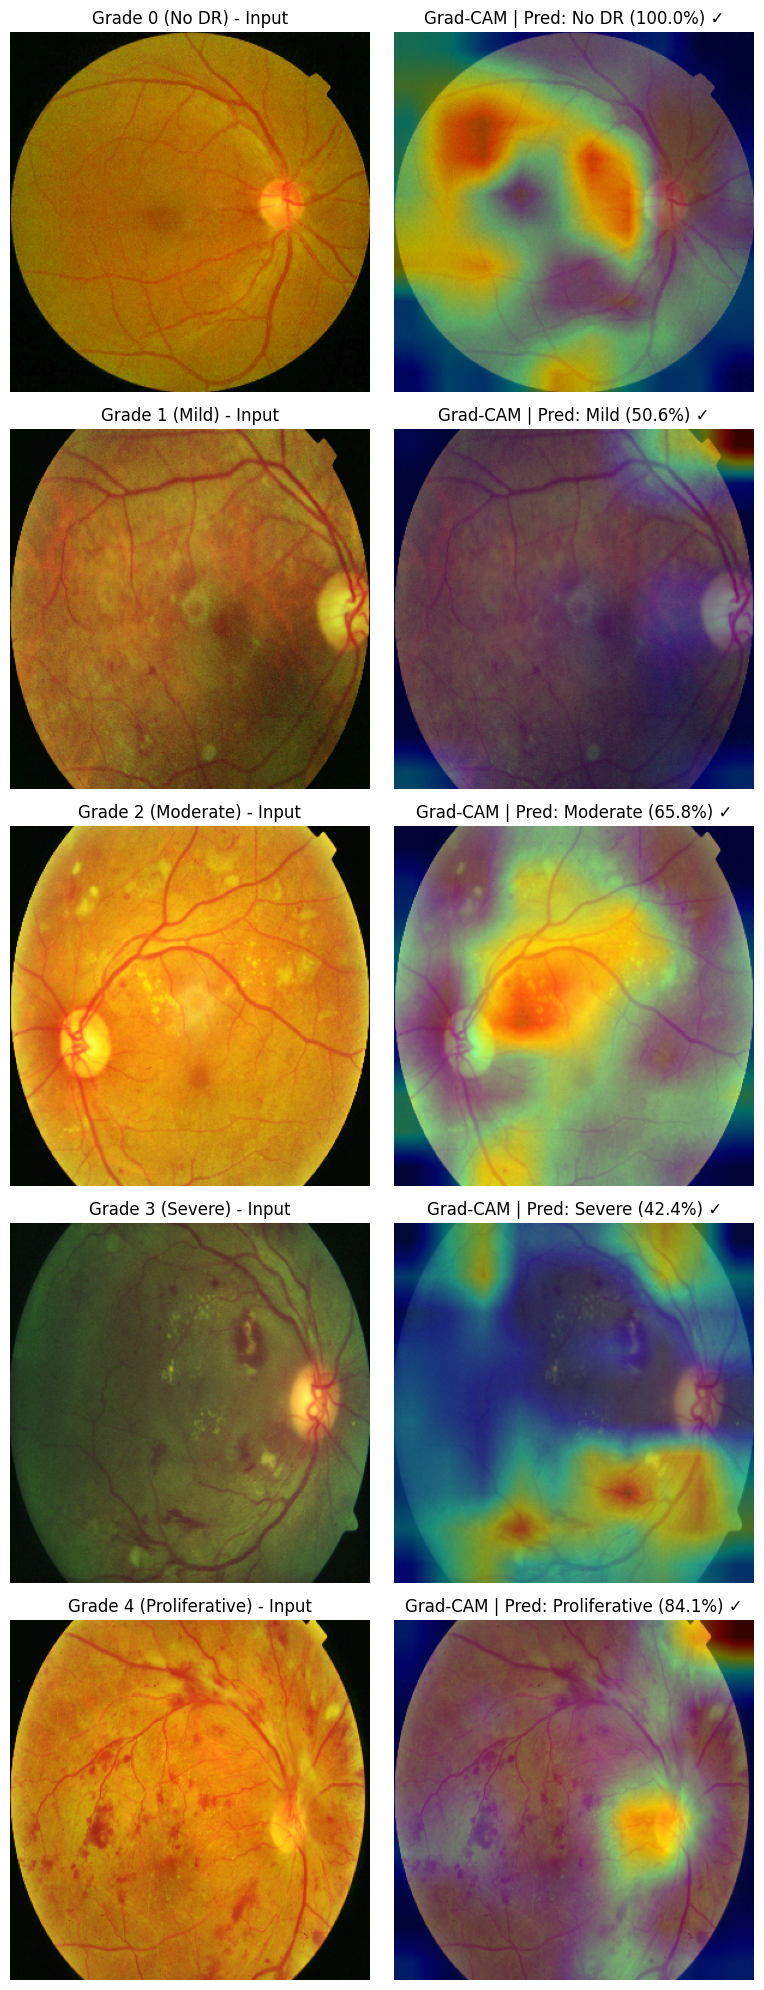

In [24]:

NUM_GRADES = 5
fig, axes = plt.subplots(NUM_GRADES, 2, figsize=(8, 4 * NUM_GRADES))

MAX_CANDIDATES = 20  # how many test images per grade to try before giving up

for grade in range(NUM_GRADES):
    grade_rows = test_df[test_df['diagnosis'] == grade].reset_index(drop=True)
    if len(grade_rows) == 0:
        for col in range(2):
            axes[grade, col].axis('off')
            axes[grade, col].set_title(f"Grade {grade} ({CLASS_NAMES[grade]}) - no test sample")
        continue

    found = False
    for i in range(min(MAX_CANDIDATES, len(grade_rows))):
        sample_row = grade_rows.iloc[i]
        filepath = sample_row['filepath']
        true_grade = int(sample_row['diagnosis'])

        display_img = load_display_image(filepath)
        model_input = load_model_input(display_img)

        heatmap, pred_class, pred_prob, pred_probs = make_gradcam_heatmap(
            model_input, backbone_model, head_model, class_index=None
        )

        if pred_class == true_grade:
            found = True
            break

    # If no correct prediction found in the first MAX_CANDIDATES, fall back
    # to the last one tried (so we still show something for that grade).
    overlay = overlay_heatmap(display_img, heatmap, alpha=0.4)

    axes[grade, 0].imshow(display_img)
    axes[grade, 0].axis('off')
    axes[grade, 0].set_title(f"Grade {true_grade} ({CLASS_NAMES[true_grade]}) - Input")

    axes[grade, 1].imshow(overlay)
    axes[grade, 1].axis('off')
    correct = "✓" if pred_class == true_grade else "✗"
    axes[grade, 1].set_title(
        f"Grad-CAM | Pred: {CLASS_NAMES[pred_class]} "
        f"({pred_prob*100:.1f}%) {correct}"
    )

plt.tight_layout()
plt.savefig('/kaggle/working/gradcam_per_grade.png', dpi=120)
plt.show()

## Cell 19- Training summary

In [25]:


import json

summary = {
    "final_test_accuracy": round(float(test_accuracy) * 100, 2),
    "final_test_qwk": round(float(test_qwk), 4),

    "phase1_final_train_accuracy": round(float(history1.history['accuracy'][-1]) * 100, 2),
    "phase1_final_val_accuracy": round(float(history1.history['val_accuracy'][-1]) * 100, 2),

    "phase2_final_train_accuracy": round(float(history2.history['accuracy'][-1]) * 100, 2),
    "phase2_final_val_accuracy": round(float(history2.history['val_accuracy'][-1]) * 100, 2),

    "phase1_best_val_accuracy": round(max(history1.history['val_accuracy']) * 100, 2),
    "phase2_best_val_accuracy": round(max(history2.history['val_accuracy']) * 100, 2),

    "best_overall_val_accuracy": round(max(
        history1.history['val_accuracy'] +
        history2.history['val_accuracy']
    ) * 100, 2),

    "model": "EfficientNetB3 + CBAM",
    "num_classes": 5
}

with open("/kaggle/working/training_summary.json", "w") as f:
    json.dump(summary, f, indent=4)

print("✅ training_summary.json saved to /kaggle/working/")

✅ training_summary.json saved to /kaggle/working/
